<a href="https://colab.research.google.com/github/evelynkim04/QM2_coursework/blob/main/2019_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
url = "https://data.london.gov.uk/download/v8pow/87e880c2-34bd-4d86-8895-e8c5344f358e/traffic-flow-borough.xlsx"

cars = pd.read_excel(url, sheet_name="Traffic Flows - Cars")
allv = pd.read_excel(url, sheet_name="Traffic Flows - All vehicles")

def clean_year(col):
    try:
        return int(col.split()[0])
    except:
        return col

cars.columns = [clean_year(c) for c in cars.columns]
allv.columns = [clean_year(c) for c in allv.columns]

years = list(range(2019, 2023))

cars_df = cars[["LA Code", "Local Authority"] + years]
vehicles_df = allv[["LA Code", "Local Authority"] + years]

In [ ]:
#Traffic Flow Car Output
cars_df

,LA Code,Local Authority,2019,2020,2021,2022
0,NaN,NaN,NaN,NaN,NaN,NaN
1,E09000001,City of London,100.9,76.1,84.1,77.5
2,E09000002,Barking and Dagenham,506.6,415.6,456.7,484.6
3,E09000003,Barnet,1421.2,1108.3,1246.4,1270.6
4,E09000004,Bexley,814.1,666.1,749.2,772.6
5,E09000005,Brent,806.2,677.3,745.6,742.4
6,E09000006,Bromley,1179.6,939.6,1089.9,1117.1
7,E09000007,Camden,355.4,278.6,311.3,316.1
8,E09000008,Croydon,1084.1,884.3,1011.6,1036.3
9,E09000009,Ealing,1063.8,881.6,960.1,990.1


In [ ]:
#Traffic Flow All Vehicle Output
vehicles_df

,LA Code,Local Authority,2019,2020,2021,2022
0,NaN,NaN,NaN,NaN,NaN,NaN
1,E09000001,City of London,150.1,116.9,128.1,120.5
2,E09000002,Barking and Dagenham,660.6,559.1,602.9,641.1
3,E09000003,Barnet,1821.9,1447.8,1617.9,1646.5
4,E09000004,Bexley,1033.6,869.0,964.4,991.8
5,E09000005,Brent,1024.5,883.3,965.2,962.1
6,E09000006,Bromley,1468.5,1195.1,1367.6,1400.4
7,E09000007,Camden,483.1,392.1,435.4,445.0
8,E09000008,Croydon,1357.5,1135.8,1285.5,1318.8
9,E09000009,Ealing,1369.6,1161.7,1256.5,1292.9


In [ ]:
import pandas as pd
import requests
from io import BytesIO

# data in population
df_path_pop = (
    "https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/"
    "populationandmigration/populationestimates/datasets/"
    "populationestimatesforukenglandandwalesscotlandandnorthernireland/"
    "mid2024/mye24tablesuk.xlsx"
)

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(df_path_pop, headers=headers)
response.raise_for_status()

pop_df = pd.read_excel(BytesIO(response.content), sheet_name="MYE5", header=7)


In [ ]:
#Output pandas in population
pop_filtered_df = pop_df.iloc[201:234]
def clean_pop_df_column_name(col_name):
    if isinstance(col_name, str) and col_name.startswith('Mid-'):
        try:
            return int(col_name.replace('Mid-', ''))
        except ValueError:
            return col_name # Return original if conversion fails
    return col_name

pop_filtered_df.columns = [clean_pop_df_column_name(col) for col in pop_filtered_df.columns]
pop_filtered_df

,Code,Name,Geography,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,Estimated Population mid-2023,2023 people per sq. km,Estimated Population mid-2022,2022 people per sq. km,...,Estimated Population mid-2015,2015 people per sq. km,Estimated Population mid-2014,2014 people per sq. km,Estimated Population mid-2013,2013 people per sq. km,Estimated Population mid-2012,2012 people per sq. km,Estimated Population mid-2011,2011 people per sq. km
201,E12000007,LONDON,Region,1571.9584,9089736,5782,8999705,5725,8871368,5644,...,8659545,5509,8547192,5437,8438987,5368,8320767,5293,8204407,5219
202,E09000007,Camden,London Borough,21.7785,216943,9961,217235,9975,217352,9980,...,221032,10149,221095,10152,221348,10164,219647,10085,220087,10106
203,E09000001,City of London,London Borough,2.8899,15111,5229,13606,4708,11615,4019,...,7668,2653,7567,2618,7537,2608,7514,2600,7412,2565
204,E09000012,Hackney,London Borough,19.0440,266758,14007,265411,13937,261814,13748,...,261929,13754,258735,13586,255646,13424,251193,13190,247182,12980
205,E09000013,Hammersmith and Fulham,London Borough,16.4013,188687,11504,187479,11431,185822,11330,...,187246,11417,186659,11381,186056,11344,184439,11245,182445,11124
206,E09000014,Haringey,London Borough,29.6063,263850,8912,263362,8895,262078,8852,...,272938,9219,268901,9083,265054,8953,259312,8759,255540,8631
207,E09000019,Islington,London Borough,14.8579,223024,15010,222333,14964,219769,14791,...,218255,14689,214986,14469,212604,14309,208762,14051,206285,13884
208,E09000020,Kensington and Chelsea,London Borough,12.1256,144518,11918,146499,12082,146336,12068,...,156149,12878,156178,12880,156823,12933,157240,12968,158251,13051
209,E09000022,Lambeth,London Borough,26.8071,316920,11822,318738,11890,317657,11850,...,322881,12045,318196,11870,314375,11727,310449,11581,304481,11358
210,E09000023,Lewisham,London Borough,35.1460,301255,8572,300225,8542,299164,8512,...,295364,8404,291086,8282,286056,8139,281011,7996,276938,7880


In [ ]:
#Output pandas in population
pop_filtered_df = pop_df.iloc[201:234]
def clean_pop_df_column_name(col_name):
    if isinstance(col_name, str) and col_name.startswith('Mid-'):
        try:
            return int(col_name.replace('Mid-', ''))
        except ValueError:
            return col_name # Return original if conversion fails
    return col_name

pop_filtered_df.columns = [clean_pop_df_column_name(col) for col in pop_filtered_df.columns]

desired_columns = [
    'Code',
    'Name',
    'Geography',
    'Area (sq km)',
    'Estimated Population mid-2022',
    '2022 people per sq. km',
    'Estimated Population mid-2019',
    '2019 people per sq. km'
]

pop_selected_columns_df = pop_filtered_df[desired_columns]
display(pop_selected_columns_df)

,Code,Name,Geography,Area (sq km),Estimated Population mid-2022,2022 people per sq. km,Estimated Population mid-2019,2019 people per sq. km
201,E12000007,LONDON,Region,1571.9584,8871368,5644,8889743,5655
202,E09000007,Camden,London Borough,21.7785,217352,9980,217136,9970
203,E09000001,City of London,London Borough,2.8899,11615,4019,8765,3033
204,E09000012,Hackney,London Borough,19.0440,261814,13748,265825,13958
205,E09000013,Hammersmith and Fulham,London Borough,16.4013,185822,11330,188562,11497
206,E09000014,Haringey,London Borough,29.6063,262078,8852,273716,9245
207,E09000019,Islington,London Borough,14.8579,219769,14791,221994,14941
208,E09000020,Kensington and Chelsea,London Borough,12.1256,146336,12068,146805,12107
209,E09000022,Lambeth,London Borough,26.8071,317657,11850,329513,12292
210,E09000023,Lewisham,London Borough,35.1460,299164,8512,305906,8704


In [ ]:
# data in earnings
df_path_earnings = "https://data.london.gov.uk/download/2z0rk/1686ef1c-b169-442d-8877-e7e49788f668/earnings-residence-borough.xlsx"

earnings_df = pd.read_excel(df_path_earnings, sheet_name="Total, weekly")


In [ ]:
import pandas as pd

raw_df = pd.read_excel(df_path_earnings, sheet_name="Total, weekly", header=None)

# Extract the first two rows to be used as header information
header_row0 = raw_df.iloc[0] # Contains years (e.g., 2002, NaN, 2003, NaN)
header_row1 = raw_df.iloc[1] # Contains sub-headers (e.g., Code, Area, Pay (£), conf %)

# Construct new column names by combining the year and sub-header
new_columns = []
current_year = None

for i in range(len(header_row0)):
    year_val = header_row0.iloc[i]
    sub_header_val = header_row1.iloc[i]

    if i < 2: # Handle the first two columns ('Code', 'Area') specifically
        new_columns.append(str(year_val).strip())
    elif pd.isna(year_val): # If year is NaN, it's a sub-header like 'conf %' under a year
        if current_year is not None:
            new_columns.append(f"{current_year} {str(sub_header_val).strip()}")
        else:
            # This case implies a NaN year_val without a preceding year, which shouldn't happen for data columns
            new_columns.append(str(sub_header_val).strip()) # Fallback for safety
    else: # Year value is present (e.g., 2002, 2003, ...)
        current_year = int(year_val)
        new_columns.append(f"{current_year} {str(sub_header_val).strip()}")

# Create the earnings_clean DataFrame by taking data from the third row onwards
# and assigning the newly constructed column names.
earnings_clean = raw_df.iloc[2:].copy()
earnings_clean.columns = new_columns
earnings_clean = earnings_clean.reset_index(drop=True)

# Remove all 'conf %' columns
columns_to_drop = [col for col in earnings_clean.columns if 'conf %' in col]
earnings_clean = earnings_clean.drop(columns=columns_to_drop)

# Identify the columns for 'Pay (£)' for years 2011 to 2024
years_to_keep = list(range(2019, 2023))
pay_columns = [f"{year} Pay (£)" for year in years_to_keep]

# Ensure 'Code' and 'Area' are always kept
final_columns = ['Code', 'Area'] + pay_columns

# Filter earnings_clean to retain only these selected columns
earnings_clean = earnings_clean[final_columns]

earnings_clean_df = earnings_clean.iloc[0:34]

print("Cleaned earnings_clean DataFrame:")
earnings_clean_df

Cleaned earnings_clean DataFrame:


,Code,Area,2019 Pay (£),2020 Pay (£),2021 Pay (£),2022 Pay (£)
0,NaN,NaN,NaN,NaN,NaN,NaN
1,00AA,City of London,#,#,#,#
2,00AB,Barking and Dagenham,471,486.7,508.7,536.6
3,00AC,Barnet,536.4,538.8,574.9,624.3
4,00AD,Bexley,553.4,566.5,586.6,634.4
5,00AE,Brent,524,531.8,555.7,556.6
6,00AF,Bromley,638.3,613.2,666.6,704.2
7,00AG,Camden,662,623,695,699.2
8,00AH,Croydon,561.7,565.1,613.3,667
9,00AJ,Ealing,532.2,566.8,582.6,597.4


In [ ]:
import io
import zipfile
import requests
import pandas as pd

# Make pandas show EVERYTHING
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


def load_full_pm25_summary(zip_url):
    """
    Downloads LAEI ZIP file and returns the FULL PM2.5 Summary sheet as a DataFrame
    """
    # Download ZIP
    response = requests.get(zip_url)
    response.raise_for_status()

    # Open ZIP
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # Find Excel file
        excel_name = [f for f in z.namelist() if f.lower().endswith(".xlsx")][0]

        # Load Excel
        excel_bytes = io.BytesIO(z.read(excel_name))
        df = pd.read_excel(excel_bytes, sheet_name="PM2.5 Summary")

    return df


# ================= URLs =================

url_2019 = (
    "https://data.london.gov.uk/download/"
    "london-atmospheric-emissions-inventory--laei--2019/"
    "17d21cd1-892e-4388-9fea-b48c1b61ee3c/"
    "LAEI-2019-Emissions-Summary-including-Forecast.zip"
)

url_2022 = (
    "https://data.london.gov.uk/download/2lg5g/4ql/"
    "LAEI2022-Emissions-Summary-Excel.zip"
)

# ================= Load FULL PM2.5 sheets =================

pm25_2019_full = load_full_pm25_summary(url_2019)
pm25_2022_full = load_full_pm25_summary(url_2022)


In [ ]:

result_2022 = pm25_2022_full.iloc[[6, 77], 11:]

result_2022

,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46
6,Row Labels,Barking and Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,Enfield,Greenwich,Hackney,Hammersmith and Fulham,Haringey,Harrow,Havering,Hillingdon,Hounslow,Islington,Kensington and Chelsea,Kingston,Lambeth,Lewisham,Merton,Newham,Redbridge,Richmond,Southwark,Sutton,Tower Hamlets,Waltham Forest,Wandsworth,Non-GLA,Westminster,City of London,Grand Total
77,Grand Total,77.270519,133.32283,104.686048,114.930944,135.640101,68.227314,150.942346,124.123021,141.448322,114.115291,73.186536,54.910216,55.561304,76.622391,121.692274,305.30683,109.215748,64.850672,48.600211,66.996553,73.033421,85.775661,67.93263,89.734112,90.382563,78.773491,76.900867,77.950957,67.966899,67.45479,85.692503,731.589474,185.498001,26.586187,3946.921028


In [ ]:

result_2019 = pm25_2019_full.iloc[[6, 71], 11:]

result_2019

,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46
6,Row Labels,Barking and Dagenham,Barnet,Bexley,Brent,Bromley,Camden,City,City of Westminster,Croydon,Ealing,Enfield,Greenwich,Hackney,Hammersmith and Fulham,Haringey,Harrow,Havering,Hillingdon,Hounslow,Islington,Kensington and Chelsea,Kingston,Lambeth,Lewisham,Merton,Newham,Redbridge,Richmond,Southwark,Sutton,Tower Hamlets,Waltham Forest,Wandsworth,Non GLA,Grand Total
71,Grand Total,89.144025,146.784771,126.825466,112.133591,131.074954,98.035241,45.171228,184.392969,129.358847,128.534116,140.493582,115.231368,55.969963,60.478756,63.396073,80.469973,121.357687,247.134244,131.381635,56.890515,60.601096,69.384975,74.373947,70.859049,73.560127,121.318747,99.834475,77.401403,75.588366,73.020844,103.639316,75.547046,91.066451,679.499192,4009.95404


In [ ]:
# Combining "result_2019", "2019 Pay (£)" in "earnings_clean_df", "2019 people per sq. km" in "pop_selected_columns_df", and "2019" in "vehicles_df".


In [ ]:
# Renaming "Code" to "LA Code" and "2019 Pay (£)" to "Local Authority", and filtering out rows where "LA Code" is null.

# Importing necessary libraries
import pandas as pd

df_path_earnings = "https://data.london.gov.uk/download/2z0rk/1686ef1c-b169-442d-8877-e7e49788f668/earnings-residence-borough.xlsx"

raw_df = pd.read_excel(df_path_earnings, sheet_name="Total, weekly", header=None)

# Extracting the first two rows to be used as header information
header_row0 = raw_df.iloc[0] # Contains years (e.g., 2002, NaN, 2003, NaN)
header_row1 = raw_df.iloc[1] # Contains sub-headers (e.g., Code, Area, Pay (£), conf %)

# Constructing new column names by combining the year and sub-header
new_columns = []
current_year = None

for i in range(len(header_row0)):
    year_val = header_row0.iloc[i]
    sub_header_val = header_row1.iloc[i]

    if i < 2: # Handling the first two columns ('Code', 'Area') specifically
        new_columns.append(str(year_val).strip())
    elif pd.isna(year_val): # If year is NaN, it's a sub-header like 'conf %' under a year
        if current_year is not None:
            new_columns.append(f"{current_year} {str(sub_header_val).strip()}")
        else:
            # This case implies a NaN year_val without a preceding year, which shouldn't happen for data columns
            new_columns.append(str(sub_header_val).strip()) # Fallback for safety
    else: # Year value is present (e.g., 2002, 2003, ...)
        current_year = int(year_val)
        new_columns.append(f"{current_year} {str(sub_header_val).strip()}")

# Creating the "earnings_clean" dataframe by taking data from the third row onwards and assigning the newly constructed column names.
earnings_clean = raw_df.iloc[2:].copy()
earnings_clean.columns = new_columns
earnings_clean = earnings_clean.reset_index(drop=True)

# Removing all 'conf %' columns
columns_to_drop = [col for col in earnings_clean.columns if 'conf %' in col]
earnings_clean = earnings_clean.drop(columns=columns_to_drop)

# Identifying the columns for 'Pay (£)' for years 2011 to 2024
years_to_keep = list(range(2019, 2023))
pay_columns = [f"{year} Pay (£)" for year in years_to_keep]

# Ensuring that 'Code' and 'Area' are always kept
final_columns = ['Code', 'Area'] + pay_columns

# Filtering "earnings_clean" to retain only these selected columns
earnings_clean = earnings_clean[final_columns]

earnings_clean_df = earnings_clean.iloc[0:34]

# Printing the first few rows of "earnings_2019_df"
earnings_2019_df = earnings_clean_df[['Code', 'Area', '2019 Pay (£)']].copy()
earnings_2019_df.rename(columns={'Code': 'LA Code', 'Area': 'Local Authority'}, inplace=True)
earnings_2019_df.dropna(subset=['LA Code'], inplace=True)

print("Prepared 2019 earnings data:")
earnings_2019_df.head()

Prepared 2019 earnings data:


,LA Code,Local Authority,2019 Pay (£)
1,00AA,City of London,#
2,00AB,Barking and Dagenham,471
3,00AC,Barnet,536.4
4,00AD,Bexley,553.4
5,00AE,Brent,524


In [ ]:
# Preparing the population density data for 2019. - Renaming "Code" to "LA Code" and "Name" to "Local Authority" and removing any rows with missing "LA Code"
population_2019_df = pop_selected_columns_df[['Code', 'Name', '2019 people per sq. km']].copy()
population_2019_df.rename(columns={'Code': 'LA Code', 'Name': 'Local Authority'}, inplace=True)
population_2019_df.dropna(subset=['LA Code'], inplace=True)

print("Prepared 2019 population data:")
population_2019_df.head()

Prepared 2019 population data:


,LA Code,Local Authority,2019 people per sq. km
201,E12000007,LONDON,5655
202,E09000007,Camden,9970
203,E09000001,City of London,3033
204,E09000012,Hackney,13958
205,E09000013,Hammersmith and Fulham,11497


In [ ]:
# Preparing traffic intensity data for 2019
vehicles_2019_df = vehicles_df[['LA Code', 'Local Authority', 2019]].copy()
vehicles_2019_df.dropna(subset=['LA Code'], inplace=True)

print("Prepared 2019 vehicles data:")
vehicles_2019_df.head()

Prepared 2019 vehicles data:


,LA Code,Local Authority,2019
1,E09000001,City of London,150.1
2,E09000002,Barking and Dagenham,660.6
3,E09000003,Barnet,1821.9
4,E09000004,Bexley,1033.6
5,E09000005,Brent,1024.5


In [ ]:
# Preparing PM2.5 air pollution data and making sure that only numeric values are present.
import pandas as pd

# Extracting borough names (excluding 'Row Labels')
borough_names = result_2019.iloc[0, 1:].values
# Extracting PM2.5 values (excluding 'Grand Total')
pm25_values = result_2019.iloc[1, 1:].values

pm25_2019_df = pd.DataFrame({
    'Local Authority': borough_names,
    '2019 PM2.5': pm25_values
})

# Filtering out specific local authority names that are not actual boroughs or are redundant
pm25_2019_df = pm25_2019_df[~pm25_2019_df['Local Authority'].isin(['Non GLA', 'Grand Total', 'City', 'City of Westminster'])].copy()

# Converting PM2.5 to numeric values
pm25_2019_df['2019 PM2.5'] = pd.to_numeric(pm25_2019_df['2019 PM2.5'])

# Maping out Local Authority names to match other dataframes where possible
name_mapping = {
    'Barking and Dagenham': 'Barking and Dagenham',
    'Barnet': 'Barnet',
    'Bexley': 'Bexley',
    'Brent': 'Brent',
    'Bromley': 'Bromley',
    'Camden': 'Camden',
    'Croydon': 'Croydon',
    'Ealing': 'Ealing',
    'Enfield': 'Enfield',
    'Greenwich': 'Greenwich',
    'Hackney': 'Hackney',
    'Hammersmith and Fulham': 'Hammersmith and Fulham',
    'Haringey': 'Haringey',
    'Harrow': 'Harrow',
    'Havering': 'Havering',
    'Hillingdon': 'Hillingdon',
    'Hounslow': 'Hounslow',
    'Islington': 'Islington',
    'Kensington and Chelsea': 'Kensington and Chelsea',
    'Kingston': 'Kingston upon Thames',
    'Lambeth': 'Lambeth',
    'Lewisham': 'Lewisham',
    'Merton': 'Merton',
    'Newham': 'Newham',
    'Redbridge': 'Redbridge',
    'Richmond': 'Richmond upon Thames',
    'Southwark': 'Southwark',
    'Sutton': 'Sutton',
    'Tower Hamlets': 'Tower Hamlets',
    'Waltham Forest': 'Waltham Forest',
    'Wandsworth': 'Wandsworth',
    'City of London': 'City of London'
}
pm25_2019_df['Local Authority'] = pm25_2019_df['Local Authority'].replace(name_mapping)

print("Prepared 2019 PM2.5 data:")
pm25_2019_df.head()

Prepared 2019 PM2.5 data:


,Local Authority,2019 PM2.5
0,Barking and Dagenham,89.144025
1,Barnet,146.784771
2,Bexley,126.825466
3,Brent,112.133591
4,Bromley,131.074954


In [ ]:
# Merging income, population density, traffic intensity, and air pollution data into one dataframe for 2019.
merged_2019_data = pd.merge(earnings_2019_df, population_2019_df, on='Local Authority', how='outer')
merged_2019_data = pd.merge(merged_2019_data, vehicles_2019_df, on='Local Authority', how='outer')
merged_2019_data = pd.merge(merged_2019_data, pm25_2019_df, on='Local Authority', how='outer')

# Ensuring 'LA Code' from earnings is used as primary, or population if earnings is missing
# The first step is to clean the LA Code from "earnings_2019_df", which might have a '00AA' format (placeholder format)and converting other LA Codes to object type to avoid dtype issues during merge.
merged_2019_data['LA Code_x'] = merged_2019_data['LA Code_x'].replace({'00AA': 'E09000001', '00AB': 'E09000002', '00AC': 'E09000003', '00AD': 'E09000004', '00AE': 'E09000005', '00AF': 'E09000006', '00AG': 'E09000007', '00AH': 'E09000008', '00AJ': 'E09000009', '00AK': 'E09000010', '00AL': 'E09000011', '00AM': 'E09000012', '00AN': 'E09000013', '00AP': 'E09000014', '00AQ': 'E09000015', '00AR': 'E09000016', '00AS': 'E09000017', '00AT': 'E09000018', '00AU': 'E09000019', '00AW': 'E09000020', '00AX': 'E09000021', '00AY': 'E09000022', '00AZ': 'E09000023', '00BA': 'E09000024', '00BB': 'E09000025', '00BC': 'E09000026', '00BD': 'E09000027', '00BE': 'E09000028', '00BF': 'E09000029', '00BG': 'E09000030', '00BH': 'E09000031', '00BJ': 'E09000032', '00BK': 'E09000033'})

merged_2019_data['LA Code'] = merged_2019_data['LA Code_x'].fillna(merged_2019_data['LA Code_y'])
merged_2019_data = merged_2019_data.drop(columns=['LA Code_x', 'LA Code_y'])

# Renaming columns for clarity
merged_2019_data.rename(columns={
    '2019 Pay (£)': '2019_Avg_Weekly_Earnings',
    '2019 people per sq. km': '2019_Population_Density',
    2019: '2019_Vehicle_Traffic'
}, inplace=True)

# Removing the 'LONDON' row from the population data as it is a region, not a borough.
merged_2019_data = merged_2019_data[merged_2019_data['Local Authority'] != 'LONDON']

# Removing rows where 'LA Code' is still NaN (non-borough entries that might have slipped through)
merged_2019_data.dropna(subset=['LA Code'], inplace=True)

print("Combined 2019 data for London boroughs:")
merged_2019_data.head()

Combined 2019 data for London boroughs:


,Local Authority,2019_Avg_Weekly_Earnings,2019_Population_Density,LA Code,2019_Vehicle_Traffic,2019 PM2.5
0,Barking and Dagenham,471,6062.0,E09000002,660.6,89.144025
1,Barnet,536.4,4502.0,E09000003,1821.9,146.784771
2,Bexley,553.4,4072.0,E09000004,1033.6,126.825466
3,Brent,524,8036.0,E09000005,1024.5,112.133591
4,Bromley,638.3,2206.0,E09000006,1468.5,131.074954


In [ ]:
# Converting non-numeric values like "#" and "!" in income dataframe to NaN values and then replacing them with the mean income to make it suitable for analysis.
merged_2019_data['2019_Avg_Weekly_Earnings'] = pd.to_numeric(merged_2019_data['2019_Avg_Weekly_Earnings'], errors='coerce')
mean_earnings = merged_2019_data['2019_Avg_Weekly_Earnings'].mean()
merged_2019_data['2019_Avg_Weekly_Earnings'].fillna(mean_earnings, inplace=True)

print("Cleaned 2019_Avg_Weekly_Earnings column:")
print(merged_2019_data[['Local Authority', '2019_Avg_Weekly_Earnings']].head())

Cleaned 2019_Avg_Weekly_Earnings column:
        Local Authority  2019_Avg_Weekly_Earnings
0  Barking and Dagenham                     471.0
1                Barnet                     536.4
2                Bexley                     553.4
3                 Brent                     524.0
4               Bromley                     638.3


/tmp/ipython-input-3618784091.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_2019_data['2019_Avg_Weekly_Earnings'].fillna(mean_earnings, inplace=True)


In [ ]:
merged_2019_data['2019_Avg_Weekly_Earnings'] = pd.to_numeric(merged_2019_data['2019_Avg_Weekly_Earnings'], errors='coerce')
mean_earnings = merged_2019_data['2019_Avg_Weekly_Earnings'].mean()
merged_2019_data['2019_Avg_Weekly_Earnings'] = merged_2019_data['2019_Avg_Weekly_Earnings'].fillna(mean_earnings)

print("Cleaned 2019_Avg_Weekly_Earnings column:")
print(merged_2019_data[['Local Authority', '2019_Avg_Weekly_Earnings']].head())

Cleaned 2019_Avg_Weekly_Earnings column:
        Local Authority  2019_Avg_Weekly_Earnings
0  Barking and Dagenham                     471.0
1                Barnet                     536.4
2                Bexley                     553.4
3                 Brent                     524.0
4               Bromley                     638.3


In [ ]:
# Printing the descriptive statistics for the merged 2019 data
print("Descriptive statistics for combined 2019 data:")
print(merged_2019_data.describe())

Descriptive statistics for combined 2019 data:
       2019_Avg_Weekly_Earnings  2019_Population_Density  \
count                 33.000000                32.000000   
mean                 599.040625              7399.593750   
std                   75.120103              3812.625578   
min                  471.000000              2206.000000   
25%                  547.600000              4514.000000   
50%                  574.900000              6077.000000   
75%                  638.300000              9816.250000   
max                  763.700000             15430.000000   

       2019_Vehicle_Traffic  2019 PM2.5  
count             33.000000   31.000000  
mean             988.248485  100.028731  
std              512.282530   38.959417  
min              150.100000   55.969963  
25%              661.600000   73.290486  
50%              834.500000   91.066451  
75%             1209.900000  124.091577  
max             2498.600000  247.134244  


In [ ]:
# Displaying the merged dataframe
print("Final merged 2019 data:")
display(merged_2019_data)

Final merged 2019 data:


,Local Authority,2019_Avg_Weekly_Earnings,2019_Population_Density,LA Code,2019_Vehicle_Traffic,2019 PM2.5
0,Barking and Dagenham,471.000000,6062.0,E09000002,660.6,89.144025
1,Barnet,536.400000,4502.0,E09000003,1821.9,146.784771
2,Bexley,553.400000,4072.0,E09000004,1033.6,126.825466
3,Brent,524.000000,8036.0,E09000005,1024.5,112.133591
4,Bromley,638.300000,2206.0,E09000006,1468.5,131.074954
5,Camden,662.000000,9970.0,E09000007,483.1,98.035241
6,City of London,599.040625,3033.0,E09000001,150.1,NaN
7,Croydon,561.700000,4518.0,E09000008,1357.5,129.358847
8,Ealing,532.200000,6613.0,E09000009,1369.6,128.534116
11,Enfield,490.100000,4148.0,E09000010,1789.3,140.493582


In [ ]:
# Running an Ordinary Least Squares (OLS) regression by importing the "statsmodels" library.
import statsmodels.formula.api as smf

# Defining the OLS model using the specified formula and data
model = smf.ols('Q("2019 PM2.5") ~ Q("2019_Vehicle_Traffic") + Q("2019_Avg_Weekly_Earnings") + Q("2019_Population_Density")', data=merged_2019_data)

# Fitting the OLS model
results = model.fit()

print("OLS model fitted successfully.")

OLS model fitted successfully.


In [ ]:
# Printing the OLS Regression Results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        Q("2019 PM2.5")   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     38.42
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.06e-09
Time:                        19:51:05   Log-Likelihood:                -126.85
No. Observations:                  30   AIC:                             261.7
Df Residuals:                      26   BIC:                             267.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

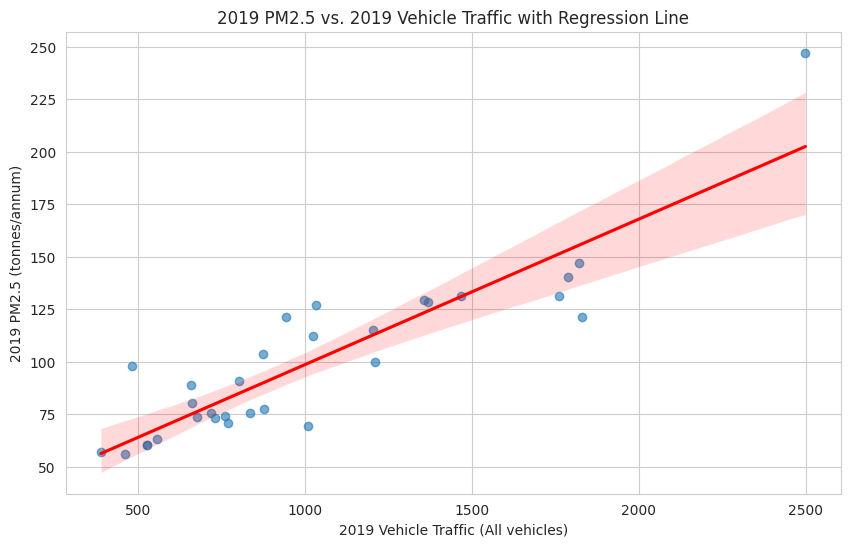

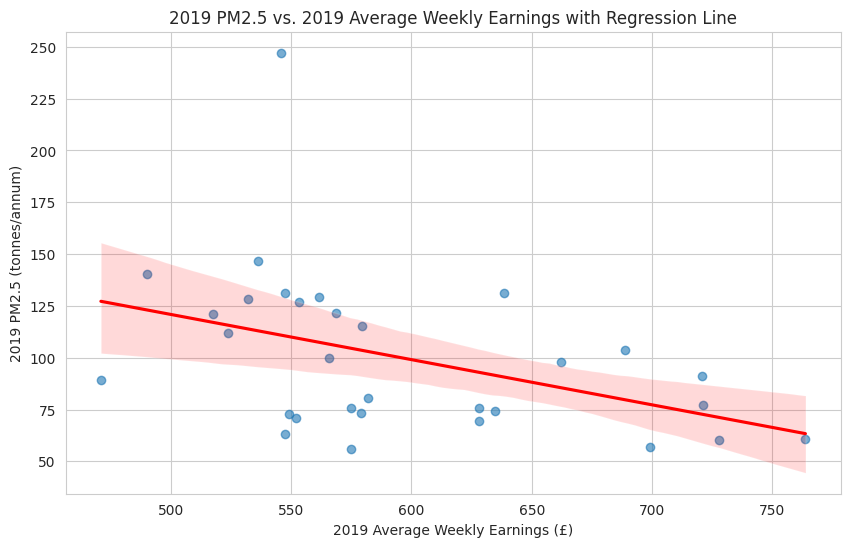

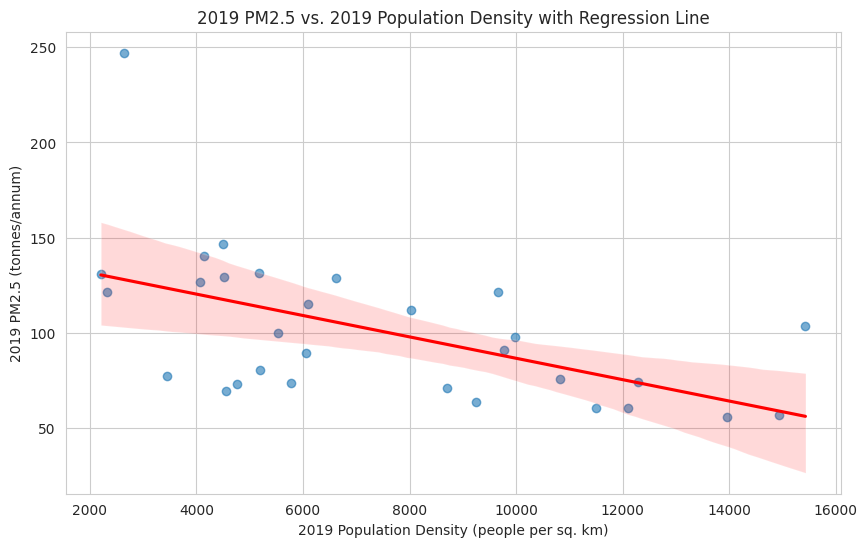

In [ ]:
# Generating scatter plots for each independent variable against air pollution with regression lines
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the aesthetic style of the plots
sns.set_style("whitegrid")

# Plot 1: 2019 PM2.5 vs. 2019_Vehicle_Traffic
plt.figure(figsize=(10, 6))
sns.regplot(x='2019_Vehicle_Traffic', y='2019 PM2.5', data=merged_2019_data, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('2019 PM2.5 vs. 2019 Vehicle Traffic with Regression Line')
plt.xlabel('2019 Vehicle Traffic (All vehicles)')
plt.ylabel('2019 PM2.5 (tonnes/annum)')
plt.show()

# Plot 2: 2019 PM2.5 vs. 2019_Avg_Weekly_Earnings
plt.figure(figsize=(10, 6))
sns.regplot(x='2019_Avg_Weekly_Earnings', y='2019 PM2.5', data=merged_2019_data, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('2019 PM2.5 vs. 2019 Average Weekly Earnings with Regression Line')
plt.xlabel('2019 Average Weekly Earnings (£)')
plt.ylabel('2019 PM2.5 (tonnes/annum)')
plt.show()

# Plot 3: 2019 PM2.5 vs. 2019_Population_Density
plt.figure(figsize=(10, 6))
sns.regplot(x='2019_Population_Density', y='2019 PM2.5', data=merged_2019_data, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('2019 PM2.5 vs. 2019 Population Density with Regression Line')
plt.xlabel('2019 Population Density (people per sq. km)')
plt.ylabel('2019 PM2.5 (tonnes/annum)')
plt.show()

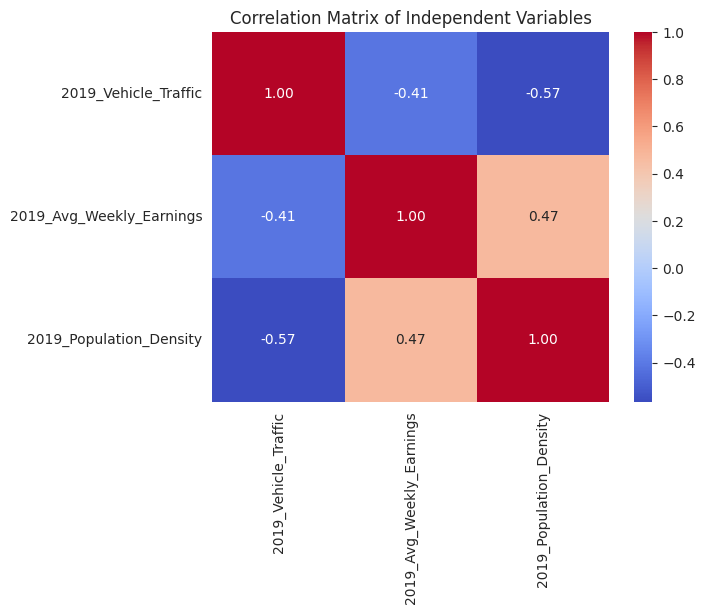

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Checking for multicollinearity
sns.heatmap(merged_2019_data[['2019_Vehicle_Traffic', '2019_Avg_Weekly_Earnings', '2019_Population_Density']].corr(), # plot a correlation matrix
            annot=True, # show the correlation values on the plot
            fmt=".2f", # set the format of the correlation values to be two decimal places
            cmap='coolwarm') # set the color palette to be coolwarm (blue for negative correlations, red for positive correlations)

plt.title('Correlation Matrix of Independent Variables') # add a title
plt.show()

In [ ]:
# calculating VIF
# This function is amended from: https://stackoverflow.com/a/51329496/4667568

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def drop_column_using_vif_(df, list_var_not_to_remove=None, thresh=5):
    '''
    Calculates VIF each feature in a pandas dataframe, and repeatedly drop the columns with the highest VIF
    A constant must be added to variance_inflation_factor or the results will be incorrect

    :param df: the pandas dataframe containing only the predictor features, not the response variable
    :param list_var_not_to_remove: the list of variables that should not be removed even though it has a high VIF. For example, dummy (or indicator) variables represent a categorical variable with three or more categories.
    :param thresh: the max VIF value before the feature is removed from the dataframe
    :return: dataframe with multicollinear features removed
    '''
    while True:
        # adding a constatnt item to the data
        df_with_const = add_constant(df)

        vif_df = pd.Series([variance_inflation_factor(df_with_const.values, i)
               for i in range(df_with_const.shape[1])], name= "VIF",
              index=df_with_const.columns).to_frame()

        # drop the const as const should not be removed
        vif_df = vif_df.drop('const')

        # drop the variables that should not be removed
        if list_var_not_to_remove is not None:
            vif_df = vif_df.drop(list_var_not_to_remove)

        print('Max VIF:', vif_df.VIF.max())

        # if the largest VIF is above the thresh, remove a variable with the largest VIF
        if vif_df.VIF.max() > thresh:
            # If there are multiple variables with the maximum VIF, choose the first one
            index_to_drop = vif_df.index[vif_df.VIF == vif_df.VIF.max()].tolist()[0]
            print('Dropping: {}'.format(index_to_drop))
            df = df.drop(columns = index_to_drop)
        else:
            # No VIF is above threshold. Exit the loop
            break

    return df


In [ ]:
ind_vars=['2019_Vehicle_Traffic', '2019_Avg_Weekly_Earnings', '2019_Population_Density']
X = merged_2019_data[ind_vars].copy()
X.dropna(inplace=True)
vif = drop_column_using_vif_(X, thresh=5)
print("The columns remaining after VIF selection are:")
print(vif.columns)

Max VIF: 1.634547410116197
The columns remaining after VIF selection are:
Index(['2019_Vehicle_Traffic', '2019_Avg_Weekly_Earnings',
       '2019_Population_Density'],
      dtype='object')
